In [1]:
import pandas as pd
path = "E:/google/"
data = pd.read_excel(path+ "数据2.2（百分比）.xlsx")
data.head()

,Unnamed: 0,a,b,c,d,e,f,g,h
0,Day1,35.67,42.94,32.28,27.49,27.12,45.99,33.63,46.41
1,Day2,45.07,40.60,34.59,29.31,30.91,44.30,29.04,49.36
2,Day3,40.91,44.15,42.92,33.87,31.30,44.16,27.10,48.90
3,Day4,45.63,47.21,44.61,32.88,31.98,46.18,31.12,47.35
4,Day5,48.68,49.26,43.88,34.06,32.89,47.80,33.78,47.25


In [2]:
import numpy as np
cpu_data = []
for instance in "abcdefgh":
    cpu_data.append(list(data[instance]))
cpu_data = np.array(cpu_data)
cpu_data

array([[35.67, 45.07, 40.91, 45.63, 48.68, 42.66, 41.32, 41.75, 46.42,
        46.7 , 43.85, 38.08, 40.31, 40.11, 37.93, 41.1 , 42.07, 38.81,
        39.71, 40.18, 44.39, 42.19, 37.45, 38.37, 37.77, 39.35, 39.83,
        39.96, 45.14, 41.22, 40.01],
       [42.94, 40.6 , 44.15, 47.21, 49.26, 47.89, 48.09, 44.11, 46.19,
        41.67, 47.17, 44.13, 43.07, 42.65, 44.55, 40.68, 43.59, 41.92,
        40.56, 44.02, 42.82, 48.1 , 46.  , 41.67, 46.21, 40.46, 39.23,
        43.07, 44.55, 46.78, 50.15],
       [32.28, 34.59, 42.92, 44.61, 43.88, 43.54, 36.47, 35.82, 32.19,
        29.54, 27.86, 34.06, 33.3 , 31.03, 25.55, 29.72, 30.3 , 33.4 ,
        40.61, 35.04, 34.44, 37.28, 31.27, 31.09, 29.14, 33.38, 39.1 ,
        45.11, 45.26, 36.77, 34.91],
       [27.49, 29.31, 33.87, 32.88, 34.06, 36.18, 31.74, 33.51, 33.36,
        29.51, 32.65, 34.05, 31.48, 33.49, 31.29, 31.88, 31.14, 32.24,
        28.83, 33.19, 29.51, 30.77, 32.38, 31.83, 30.7 , 29.86, 28.23,
        32.32, 30.32, 33.18, 31.54],


In [3]:
import numpy as np
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt

def heatmap(data, row_labels, col_labels, ax=None,
            cbar_kw={}, cbarlabel="", **kwargs):
    """
    从一个numpy数组和两个标签列表创建一个热图。
   
    data
         形状为（N，M）的2D numpy数组。
     row_labels
         长度为N且带有行标签的列表或数组。
     col_labels
         长度为M的列表或数组，带有列的标签。
     ax
         绘制热图的`matplotlib.axes.Axes`实例。 如果
         未提供，请使用当前轴或创建一个新轴。 (可选的。)
     cbar_kw
         带有`matplotlib.Figure.colorbar`参数的字典。 可选的。
     cbarlabel
         颜色条的标签。 可选的。
     **kwargs
         所有其他参数都转发给“imshow”。
    """

    if not ax:
        ax = plt.gca()
    #如果不在ax，挪动坐标轴

    
    im = ax.imshow(data, **kwargs)
    #画图

    #创造彩条
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    '''
    im:一个可以映射颜色的对象
    ax=ax:指示im得到的对象在哪里展示（整体）
    '''
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")
    '''
    设置y轴标签
    '''

    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks(np.arange(data.shape[0]))
    #设置x,y轴刻度间隔
    ax.set_xticklabels(col_labels)
    ax.set_yticklabels(row_labels)
    #设置横，纵轴

    # #让水平轴标签显示在顶部
    # ax.tick_params(top=True, bottom=False,
    #                labeltop=True, labelbottom=False)

    # #旋转刻度线标签并设置其对齐方式。
    # plt.setp(ax.get_xticklabels(), rotation=-30, ha="right",
    #          rotation_mode="anchor")

    #关闭spines并创建白色网格。
    #spines是连接轴刻度标记的线，而且标明了数据区域的边界
    for edge, spine in ax.spines.items():
        spine.set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ##设置x,y轴刻度间隔
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    #设置边框主刻度线，颜色为白色，线条格式为'-',线的宽度为3
    ax.tick_params(which="minor", bottom=False, left=False)
    #设置主刻度线，参数bottom, top, left, right的值为布尔值，分别代表设置绘图区四个边框线上的的刻度线是否显示
    

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}",
                     textcolors=["black", "white"],
                     threshold=None, **textkw):
    '''
     im
         要标记的AxesImage。
     data
         用于注释的数据。 如果为None，则使用图像数据。 （可选的。）
     valfmt
         热图内注释的格式。 这应该
         使用字符串格式方法，例如 “ $ {x：.2f}”，或成为
         `matplotlib.ticker.Formatter`。 （可选的。）
     textcolors
         两种颜色规格的列表或数组。 第一个代表值低于阈值，第二个代表高于阈值的值。 （可选的。）
     threshold
         以数据单位表示的值，根据该值，textcolors中的颜色是
         应用。 如果为None（默认），则将颜色图的中间用作
         分离。（ 可选的。）
     **kwargs
         所有其他参数都转发给用于创建的每个`text`调用。
         文字标签。
    '''

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()
    #保证data是一个list类型

    #将阈值标准化为图像颜色范围。
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    #将默认对齐方式设置为居中，但允许将其设置为居中
    #被textkw覆盖。
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    #获取格式化程序（如果提供了字符串）
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)
    #给热力图标注文本设置格式

    #遍历数据并为每个“pixel”创建一个“Text”。
    #根据数据更改文本的颜色。
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


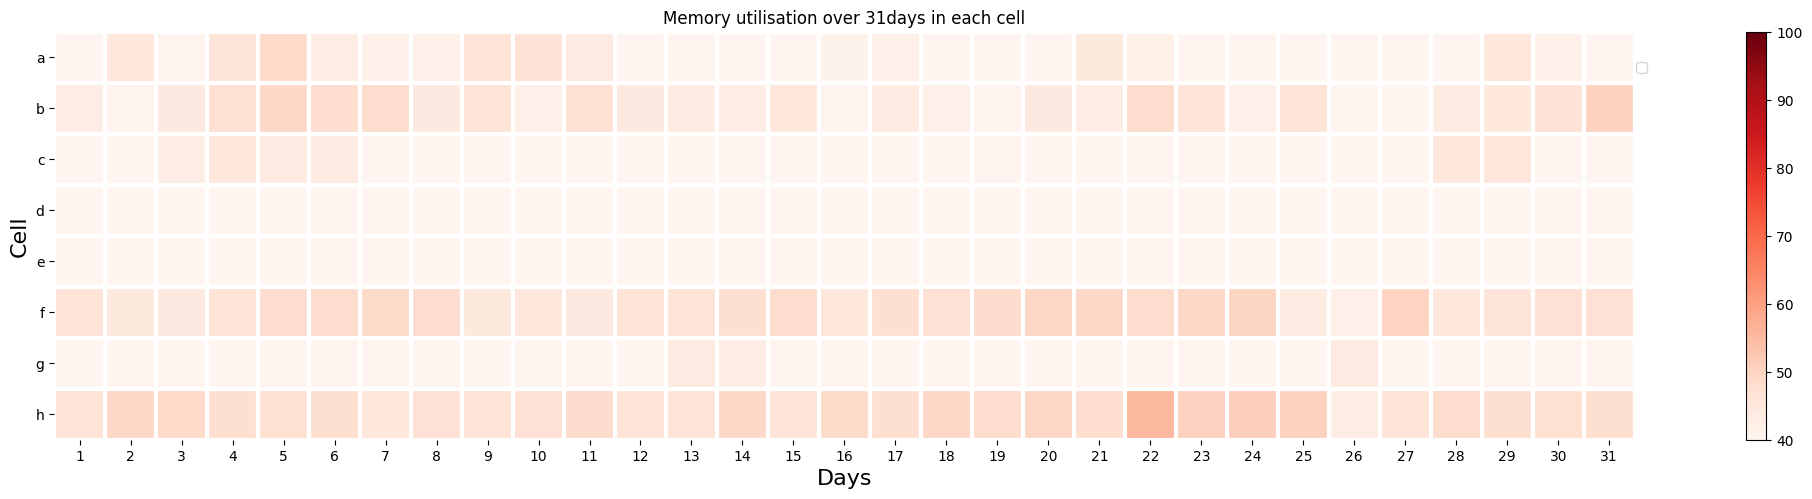

In [4]:
fig, ax = plt.subplots(figsize=(23, 5), dpi=100)


im, cbar = heatmap(cpu_data, ["a","b","c","d","e","f","g","h"], list(range(1,32)), ax=ax,
            cmap="Reds", cbarlabel="", vmin=40, vmax=100)
# texts = annotate_heatmap(im, valfmt="{x:.1f} t")
plt.title("Memory utilisation over 31days in each cell")
plt.xlabel("Days",fontsize=16)
plt.ylabel("Cell",fontsize=16)

fig.tight_layout()
plt.show()

In [ ]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

print('features:', features[0],'\nlabel:', labels[0])

d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1);

In [ ]:
import torch
A = torch.arange(20).reshape(5, 4)
A, A.shape[0]